# Fire_Recipe: Multi Collinearity Tests

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2. Simple configuration
Update only the values in this cell.

The most important settings are:

DATA_PATH: where the dataset is saved.
TARGET_RAW: the original target column in the dataset.

In [2]:
DATA_PATH = Path("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/OXON_HH_DATA.xlsx")


In [3]:
def load_tabular_data(path: Path) -> pd.DataFrame:
    """Load a tabular dataset from Excel, CSV, or Parquet."""
    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported file type: {suffix}")


df_raw = load_tabular_data(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head(2))

print("\nColumns:")
print(df_raw.columns.tolist())

Dataset shape: (301489, 22)


,s,ABP_Classification_Code,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,...,(H) Mosaic UK 7 Type,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,LSOA11CD,irs.Incident?
0,100120859623,RD04,Terraced,N,10,1.0,0,3,12.0,11,...,22,F22 Boomerang Boarders,13,0,N,0,2,JX32,E01028635,N
1,10002188486,RD02,Detached,N,11,1.0,0,4,12.0,11,...,10,C10 Wealthy Landowners,19,0,N,0,8,JX12,E01028762,N



Columns:
['s', 'ABP_Classification_Code', 'ABP_Classification_Desc', 'Communal Household Flag', '(H) Age - Fine', '(H) Household Composition', '(H) Presence of Elderly Parent', '(H) Number of Adults in Household', '(H) Family Lifestage v3', '(H) Length of Residency', '(H) Property Type 2011', '(H) Tenure 2011', '(H) Mosaic UK 7 Type', '(H) Mosaic UK 7 Type Label', '(H) Affluence v2', '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3', '(H) Household Income v3 - Bands', 'Station_Ground_Code', 'LSOA11CD', 'irs.Incident?']


In [4]:
df_raw.rename(columns = {'s':'Addressbase UPRN','irs.Incident?':'Incident?'}, inplace =True)
df_raw.drop(columns = ['ABP_Classification_Code','(H) Mosaic UK 7 Type','LSOA11CD'], inplace = True)
df_raw.head(2)

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,Incident?
0,100120859623,Terraced,N,10,1.0,0,3,12.0,11,4,0,F22 Boomerang Boarders,13,0,N,0,2,JX32,N
1,10002188486,Detached,N,11,1.0,0,4,12.0,11,4,0,C10 Wealthy Landowners,19,0,N,0,8,JX12,N


In [5]:
df_raw.shape

(301489, 19)

In [6]:
features = df_raw.loc[:, ~df_raw.columns.isin(['Incident?'])]
target = df_raw.loc[:, df_raw.columns.isin(['Incident?'])]

In [7]:
features

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code
0,100120859623,Terraced,N,10,1.0,0,3,12.0,11,4,0,F22 Boomerang Boarders,13,0,N,0,2,JX32
1,10002188486,Detached,N,11,1.0,0,4,12.0,11,4,0,C10 Wealthy Landowners,19,0,N,0,8,JX12
2,100120928150,Terraced,N,10,1.0,0,3,12.0,11,4,0,F22 Boomerang Boarders,13,0,N,0,2,JX24
3,100120926921,Terraced,N,10,9.0,0,2,12.0,11,4,0,F22 Boomerang Boarders,15,0,N,0,2,JX24
4,10002188491,Semi-Detached,N,7,8.0,0,3,8.0,11,4,0,C11 Rural Vogue,15,0,N,0,5,JX12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301484,100120966641,Caravan,Y,0,5.0,0,1,3.0,1,4,1,C11 Rural Vogue,11,0,N,2,8,JX12
301485,100120916314,Dwelling,N,0,5.0,0,1,0.0,2,4,1,H35 Flying Solo,9,0,N,0,3,JX23
301486,100121312540,Caravan,N,0,9.0,0,2,1.0,6,0,1,H35 Flying Solo,17,0,N,0,4,JX22
301487,10013983867,Dwelling,N,0,6.0,0,2,0.0,1,1,1,O66 Student Scene,8,0,N,0,3,JX30


The dataset - lack of multicollinearity
The assumption of a lack of multicollinearity requires there to be no strong correlation between any features (assuming you have more than one feature to predict  𝑦
 !)

We will only be modelling progression using a single feature at a time, so independence of the features isn't really a factor here. But let's look at it anyway.

Compute the correlation matrix of the dataset using the .corr() method. Remember, you only want to check the features against each other, not the target variable!

In [8]:
#cmatrix = features.corr()
#data[['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']].corr()
#cmatrix

In [9]:
#cmatrix[cmatrix>0.1]

In [10]:
#sns.heatmap(cmatrix, cmap='coolwarm', square=True, )

### categorical Correlation:

In [11]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#!pip install dython
from dython.nominal import associations # correlation calculation
from scipy.stats import chi2_contingency #chi square test

In [12]:
# using df_raw:

In [13]:
data = df_raw.copy()
data.head(3)

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,Incident?
0,100120859623,Terraced,N,10,1.0,0,3,12.0,11,4,0,F22 Boomerang Boarders,13,0,N,0,2,JX32,N
1,10002188486,Detached,N,11,1.0,0,4,12.0,11,4,0,C10 Wealthy Landowners,19,0,N,0,8,JX12,N
2,100120928150,Terraced,N,10,1.0,0,3,12.0,11,4,0,F22 Boomerang Boarders,13,0,N,0,2,JX24,N


In [14]:
crosstab = pd.crosstab( data['Communal Household Flag'], data['(H) Presence of Elderly Parent']) # create a contingecy table
crosstab

(H) Presence of Elderly Parent,0,1
Communal Household Flag,,
N,297688,1536
Y,2265,0


### P_value:
##### p value of chi-square test: 0.5460 -> This p value means that there is no statistically significant relationship

##### p value of chi-square test: 0.0045 -> This p-value means that there is a statistically significant relationship between attrition and department.



In [15]:
chi_square_stat, p_value, _, _ = chi2_contingency(crosstab) # chi-square test
print(f'p value of chi-square test:{p_value:.3f}')

p value of chi-square test:0.001


In [16]:
crosstab = pd.crosstab(data['(H) Household Income v3 - Bands'], data['(H) Affluence v2']) # create a contingecy table
crosstab

(H) Affluence v2,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
(H) Household Income v3 - Bands,,,,,,,,,,,,,,,,,,,,
0,630,1137,1512,2452,1958,2049,1737,1507,1146,1349,1108,1021,1439,1971,1741,1851,1053,296,62,2
1,208,421,608,953,1103,1156,1099,907,825,804,709,685,828,845,847,1196,1780,1371,721,45
2,231,714,1098,1805,2513,2814,3061,2947,2696,2171,2045,2081,2016,2847,3426,3383,3474,3027,2758,734
3,19,110,309,642,1373,2145,2461,2763,3397,3296,3108,2672,2784,2899,3029,3312,3911,4619,5014,1742
4,1,20,69,186,411,893,1262,1816,2528,3216,3089,3199,3306,3249,3235,3223,3365,3423,3766,2766
5,0,1,3,24,76,233,448,779,1322,1744,2075,2452,2837,3068,3098,2964,3030,3084,3579,2756
6,0,0,0,5,14,42,115,308,572,940,1288,1898,2414,2681,2844,2838,3023,3219,3682,3834
7,0,0,0,1,1,3,14,65,151,297,505,925,1309,1785,2750,3623,4425,5823,6530,8721
8,0,0,0,0,0,0,0,1,4,4,6,16,30,83,190,366,581,1404,3577,8531


In [17]:
chi_square_stat, p_value, _, _ = chi2_contingency(crosstab) # chi-square test
print(f'p value of chi-square test:{p_value:.9f}')

p value of chi-square test:0.000000000


In [18]:
correlation_matrix = associations(features, compute_only=True)["corr"] # gives correlation between all variables in the dataset
#correlation = correlation_matrix.loc[['(H) Household Income v3 - Bands']]['(H) Affluence v2'].values.item() # We extracted correlation between attrition and department
#print(f'Assosiation between (H) Household Income v3 - Bands and (H) Affluence v2 is {correlation:.3f}')

In [19]:
#correlation = correlation_matrix.loc[ ['(H) Household Income v3 - Bands']]['(H) Affluence v2'].values.item() # We extracted correlation between attrition and age
#print(f'Assosiation between Attrition and Age is {correlation:.3f}')

In [20]:
correlation_matrix

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code
Addressbase UPRN,1.000000,0.181235,0.060508,0.193405,-0.024599,0.007021,0.059188,0.186887,0.270565,0.171343,0.076730,0.406696,0.016698,0.048693,0.088142,-0.070417,-0.128163,0.186442
ABP_Classification_Desc,0.181235,1.000000,0.057176,0.251249,0.246784,0.031751,0.221000,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,0.156497,0.162221,0.182317,0.384877,0.136314
Communal Household Flag,0.060508,0.057176,1.000000,0.103079,0.041467,0.006226,0.058250,0.127133,0.116537,0.037795,0.036358,0.215142,0.059931,0.015309,0.054998,0.033869,0.010499,0.096610
(H) Age - Fine,0.193405,0.251249,0.103079,1.000000,-0.089540,-0.011981,-0.014131,0.878478,0.518881,0.139995,-0.088239,0.684878,0.298033,0.250549,0.138154,-0.411562,-0.302462,0.171701
(H) Household Composition,-0.024599,0.246784,0.041467,-0.089540,1.000000,-0.025955,-0.157030,-0.171118,-0.142284,-0.178576,0.165595,0.355922,-0.203559,0.181474,0.134962,-0.181781,-0.262248,0.138956
(H) Presence of Elderly Parent,0.007021,0.031751,0.006226,-0.011981,-0.025955,1.000000,0.121973,0.001589,0.034658,0.019348,-0.013529,0.058833,0.023773,-0.016288,0.000407,0.014182,0.036556,0.015945
(H) Number of Adults in Household,0.059188,0.221000,0.058250,-0.014131,-0.157030,0.121973,1.000000,0.099241,0.151094,0.213778,-0.046330,0.371483,0.010483,-0.221997,0.020234,0.125103,0.252148,0.068071
(H) Family Lifestage v3,0.186887,0.316790,0.127133,0.878478,-0.171118,0.001589,0.099241,1.000000,0.529574,0.232219,-0.101972,0.585804,0.298714,0.154488,0.093151,-0.150601,-0.145787,0.172613
(H) Length of Residency,0.270565,0.250087,0.116537,0.518881,-0.142284,0.034658,0.151094,0.529574,1.000000,0.223503,-0.041265,0.472589,0.213312,0.069302,0.084043,-0.151812,-0.115161,0.104079
(H) Property Type 2011,0.171343,0.848508,0.037795,0.139995,-0.178576,0.019348,0.213778,0.232219,0.223503,1.000000,-0.246987,0.650408,0.320435,-0.107903,0.081968,0.182380,0.208961,0.200637


In [21]:
#correlation_matrix_plot = associations(features, compute_only=False, figsize=(15,15)) 
# Compute only default value is False, it give correlation heatmap of all variables
#correlation_matrix_plot

In [22]:
correlation_matrix = correlation_matrix[correlation_matrix > 0.25]
correlation_matrix

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code
Addressbase UPRN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.270565,NaN,NaN,0.406696,NaN,NaN,NaN,NaN,NaN,NaN
ABP_Classification_Desc,NaN,1.000000,NaN,0.251249,NaN,NaN,NaN,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,NaN,NaN,NaN,0.384877,NaN
Communal Household Flag,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(H) Age - Fine,NaN,0.251249,NaN,1.000000,NaN,NaN,NaN,0.878478,0.518881,NaN,NaN,0.684878,0.298033,0.250549,NaN,NaN,NaN,NaN
(H) Household Composition,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.355922,NaN,NaN,NaN,NaN,NaN,NaN
(H) Presence of Elderly Parent,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(H) Number of Adults in Household,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.371483,NaN,NaN,NaN,NaN,0.252148,NaN
(H) Family Lifestage v3,NaN,0.316790,NaN,0.878478,NaN,NaN,NaN,1.000000,0.529574,NaN,NaN,0.585804,0.298714,NaN,NaN,NaN,NaN,NaN
(H) Length of Residency,0.270565,0.250087,NaN,0.518881,NaN,NaN,NaN,0.529574,1.000000,NaN,NaN,0.472589,NaN,NaN,NaN,NaN,NaN,NaN
(H) Property Type 2011,NaN,0.848508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.650408,0.320435,NaN,NaN,NaN,NaN,NaN


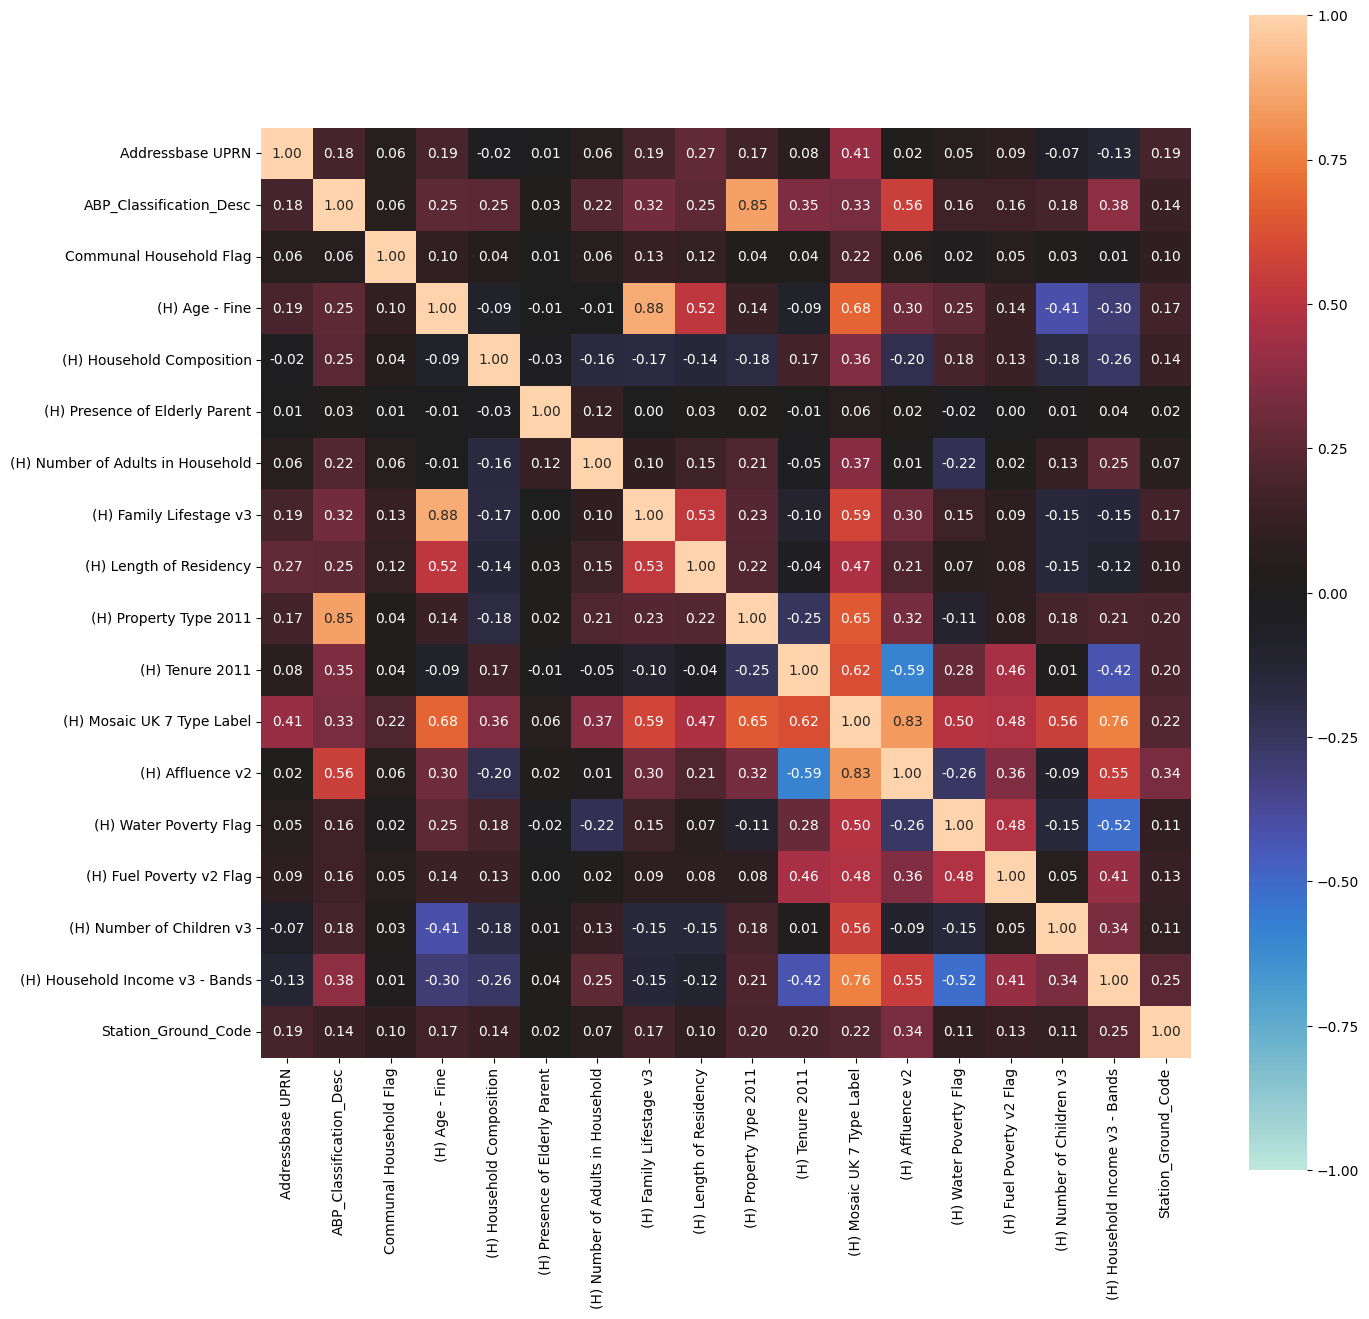

In [23]:
correlation_matrix_plot = associations(features, compute_only=False, figsize=(15,15)) 

In [24]:
correlation_matrix_0 = correlation_matrix.fillna(0)
correlation_matrix_0['total'] =correlation_matrix_0.sum(axis =1)
correlation_matrix_0

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,total
Addressbase UPRN,1.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.270565,0.000000,0.000000,0.406696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.677261
ABP_Classification_Desc,0.000000,1.000000,0.0,0.251249,0.000000,0.0,0.000000,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,0.000000,0.000000,0.000000,0.384877,0.000000,4.285623
Communal Household Flag,0.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
(H) Age - Fine,0.000000,0.251249,0.0,1.000000,0.000000,0.0,0.000000,0.878478,0.518881,0.000000,0.000000,0.684878,0.298033,0.250549,0.000000,0.000000,0.000000,0.000000,3.882068
(H) Household Composition,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.355922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.355922
(H) Presence of Elderly Parent,0.000000,0.000000,0.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
(H) Number of Adults in Household,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.371483,0.000000,0.000000,0.000000,0.000000,0.252148,0.000000,1.623631
(H) Family Lifestage v3,0.000000,0.316790,0.0,0.878478,0.000000,0.0,0.000000,1.000000,0.529574,0.000000,0.000000,0.585804,0.298714,0.000000,0.000000,0.000000,0.000000,0.000000,3.609360
(H) Length of Residency,0.270565,0.250087,0.0,0.518881,0.000000,0.0,0.000000,0.529574,1.000000,0.000000,0.000000,0.472589,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.041695
(H) Property Type 2011,0.000000,0.848508,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.650408,0.320435,0.000000,0.000000,0.000000,0.000000,0.000000,2.819352


In [25]:
correlated_features = correlation_matrix_0[correlation_matrix_0['total']>1.0]
correlated_features

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,total
Addressbase UPRN,1.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.270565,0.000000,0.000000,0.406696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.677261
ABP_Classification_Desc,0.000000,1.000000,0.0,0.251249,0.000000,0.0,0.000000,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,0.000000,0.000000,0.000000,0.384877,0.000000,4.285623
(H) Age - Fine,0.000000,0.251249,0.0,1.000000,0.000000,0.0,0.000000,0.878478,0.518881,0.000000,0.000000,0.684878,0.298033,0.250549,0.000000,0.000000,0.000000,0.000000,3.882068
(H) Household Composition,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.355922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.355922
(H) Number of Adults in Household,0.000000,0.000000,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.371483,0.000000,0.000000,0.000000,0.000000,0.252148,0.000000,1.623631
(H) Family Lifestage v3,0.000000,0.316790,0.0,0.878478,0.000000,0.0,0.000000,1.000000,0.529574,0.000000,0.000000,0.585804,0.298714,0.000000,0.000000,0.000000,0.000000,0.000000,3.609360
(H) Length of Residency,0.270565,0.250087,0.0,0.518881,0.000000,0.0,0.000000,0.529574,1.000000,0.000000,0.000000,0.472589,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.041695
(H) Property Type 2011,0.000000,0.848508,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.650408,0.320435,0.000000,0.000000,0.000000,0.000000,0.000000,2.819352
(H) Tenure 2011,0.000000,0.345507,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.616940,0.000000,0.282665,0.457648,0.000000,0.000000,0.000000,2.702760
(H) Mosaic UK 7 Type Label,0.406696,0.330530,0.0,0.684878,0.355922,0.0,0.371483,0.585804,0.472589,0.650408,0.616940,1.000000,0.830474,0.499908,0.478723,0.559012,0.762125,0.000000,8.605492


In [26]:
correlated_features[correlated_features>0]

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code,total
Addressbase UPRN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.270565,NaN,NaN,0.406696,NaN,NaN,NaN,NaN,NaN,NaN,1.677261
ABP_Classification_Desc,NaN,1.000000,NaN,0.251249,NaN,NaN,NaN,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,NaN,NaN,NaN,0.384877,NaN,4.285623
(H) Age - Fine,NaN,0.251249,NaN,1.000000,NaN,NaN,NaN,0.878478,0.518881,NaN,NaN,0.684878,0.298033,0.250549,NaN,NaN,NaN,NaN,3.882068
(H) Household Composition,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.355922,NaN,NaN,NaN,NaN,NaN,NaN,1.355922
(H) Number of Adults in Household,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.371483,NaN,NaN,NaN,NaN,0.252148,NaN,1.623631
(H) Family Lifestage v3,NaN,0.316790,NaN,0.878478,NaN,NaN,NaN,1.000000,0.529574,NaN,NaN,0.585804,0.298714,NaN,NaN,NaN,NaN,NaN,3.609360
(H) Length of Residency,0.270565,0.250087,NaN,0.518881,NaN,NaN,NaN,0.529574,1.000000,NaN,NaN,0.472589,NaN,NaN,NaN,NaN,NaN,NaN,3.041695
(H) Property Type 2011,NaN,0.848508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.650408,0.320435,NaN,NaN,NaN,NaN,NaN,2.819352
(H) Tenure 2011,NaN,0.345507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.616940,NaN,0.282665,0.457648,NaN,NaN,NaN,2.702760
(H) Mosaic UK 7 Type Label,0.406696,0.330530,NaN,0.684878,0.355922,NaN,0.371483,0.585804,0.472589,0.650408,0.616940,1.000000,0.830474,0.499908,0.478723,0.559012,0.762125,NaN,8.605492


In [27]:
list = []
for i in range(0, correlation_matrix.shape[1]):
    if [correlation_matrix[correlation_matrix.iloc[i] > 0.1]==True]:
        list.append(correlation_matrix.iloc[i])
df_list = pd.DataFrame(list)
df_list

,Addressbase UPRN,ABP_Classification_Desc,Communal Household Flag,(H) Age - Fine,(H) Household Composition,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Property Type 2011,(H) Tenure 2011,(H) Mosaic UK 7 Type Label,(H) Affluence v2,(H) Water Poverty Flag,(H) Fuel Poverty v2 Flag,(H) Number of Children v3,(H) Household Income v3 - Bands,Station_Ground_Code
Addressbase UPRN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.270565,NaN,NaN,0.406696,NaN,NaN,NaN,NaN,NaN,NaN
ABP_Classification_Desc,NaN,1.000000,NaN,0.251249,NaN,NaN,NaN,0.316790,0.250087,0.848508,0.345507,0.330530,0.558075,NaN,NaN,NaN,0.384877,NaN
Communal Household Flag,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(H) Age - Fine,NaN,0.251249,NaN,1.000000,NaN,NaN,NaN,0.878478,0.518881,NaN,NaN,0.684878,0.298033,0.250549,NaN,NaN,NaN,NaN
(H) Household Composition,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.355922,NaN,NaN,NaN,NaN,NaN,NaN
(H) Presence of Elderly Parent,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
(H) Number of Adults in Household,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.371483,NaN,NaN,NaN,NaN,0.252148,NaN
(H) Family Lifestage v3,NaN,0.316790,NaN,0.878478,NaN,NaN,NaN,1.000000,0.529574,NaN,NaN,0.585804,0.298714,NaN,NaN,NaN,NaN,NaN
(H) Length of Residency,0.270565,0.250087,NaN,0.518881,NaN,NaN,NaN,0.529574,1.000000,NaN,NaN,0.472589,NaN,NaN,NaN,NaN,NaN,NaN
(H) Property Type 2011,NaN,0.848508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.650408,0.320435,NaN,NaN,NaN,NaN,NaN


In [28]:
import Image
import matplotlib.pyplot as plt

plt.plot(range(10))
plt.savefig('testplot.png')
Image.open('testplot.png').save('testplot.jpg','JPEG')

ModuleNotFoundError: No module named 'Image'